In [243]:
from pathlib import Path
from rich import print
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scipy as sp
from scipy.integrate import trapz
from scipy.signal import savgol_filter

from datetime import datetime

from gfatpy.atmo import ecmwf
from gfatpy.lidar.plot.quicklook import quicklook_xarray
from gfatpy.config import set_logger_level
from gfatpy.lidar.preprocessing import preprocess
from gfatpy.lidar.retrieval import raman
from gfatpy.lidar.utils import refill_overlap
from gfatpy.atmo import atmo, ecmwf
from gfatpy.lidar.depolarization.retrieval import (
    add_depolarization_products, particle_depolarization
)
from gfatpy.utils.utils import moving_average

set_logger_level("WARNING")
%load_ext autoreload
%autoreload 2

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
RS_FL = Path(r"W:\UGR\alhambra\1a\2023\02\22\alh_1a_Prs_rs_xf_20230222.nc")

lidar = preprocess(
    RS_FL,    
    apply_ov=True
)

In [7]:
GHK_DIR = Path(r"W:\UGR\alhambra\QA\GHK")
ETA_DIR = Path(r"W:\UGR\alhambra\QA\depolarization_calibration")

lidar = add_depolarization_products(
        lidar, ghk_dir=GHK_DIR, depo_calib_dir=ETA_DIR
    )

C:\Users\Usuario\Documents\gitlab\gfatpy\gfatpy\lidar\depolarization\retrieval.py:81: RuntimeWarning: divide by zero encountered in divide
  ratio = (signal_R / signal_T) / eta
C:\Users\Usuario\Documents\gitlab\gfatpy\gfatpy\lidar\depolarization\retrieval.py:81: RuntimeWarning: invalid value encountered in divide
  ratio = (signal_R / signal_T) / eta
C:\Users\Usuario\Documents\gitlab\gfatpy\gfatpy\lidar\depolarization\retrieval.py:82: RuntimeWarning: invalid value encountered in divide
  lvdr_ = (((GT + HT) * ratio - (GR + HR)) / ((GR - HR) - (GT - HT) * ratio)).astype(
C:\Users\Usuario\Documents\gitlab\gfatpy\gfatpy\lidar\depolarization\retrieval.py:81: RuntimeWarning: divide by zero encountered in divide
  ratio = (signal_R / signal_T) / eta
C:\Users\Usuario\Documents\gitlab\gfatpy\gfatpy\lidar\depolarization\retrieval.py:81: RuntimeWarning: invalid value encountered in divide
  ratio = (signal_R / signal_T) / eta
C:\Users\Usuario\Documents\gitlab\gfatpy\gfatpy\lidar\depolarization\r

In [8]:
import pickle

# Create a dictionary to hold the variables
data_to_save = {
    'lidar': lidar,
}

# File path to save the pickle data
pickle_file_path = Path.cwd() / 'raman_20230222'

# Save the dictionary with all variables to the pickle file
with open(pickle_file_path, 'wb') as pickle_file:
    pickle.dump(data_to_save, pickle_file)

In [ ]:
# File path to save the pickle data
pickle_file_path = Path.cwd() / 'raman_20230222'

# Load the dictionary with variables from the pickle file
with open(pickle_file_path, 'rb') as pickle_file:
    loaded_data = pickle.load(pickle_file)

# Retrieve individual variables from the loaded dictionary
lidar = loaded_data['lidar']

In [11]:
z = lidar.range.values
z

array([3.750000e+00, 7.500000e+00, 1.125000e+01, ..., 1.999125e+04,
       1.999500e+04, 1.999875e+04], dtype=float32)

In [12]:
# Molecular elastic
ecmwf_data = ecmwf.get_ecmwf_temperature_pressure(
    datetime(2023, 2, 22), heights=z
)
atmo_data= {}
for wavelength in [355, 532]:
    atmo_data[wavelength] = atmo.molecular_properties(
        wavelength, ecmwf_data.pressure, ecmwf_data.temperature, heights=z
    )

In [118]:
#Select time
time_tuple = ('20230222T020000.0', '20230222T030000.0')

lidar_sel = lidar.sel(time=slice(*time_tuple))

In [244]:
# FF
channel = '532fta'
channel_pc = '532ftp'
channel_raman = '531fta'
channel_raman_pc = '531ftp'
wave = int(channel[:-3])
wave_raman = int(channel_raman[:-3])
R_threshold = 2


P_raman = lidar_sel[f'signal_{channel_raman}'].mean('time').values
P_raman_pc = lidar_sel[f'signal_{channel_raman_pc}'].mean('time').values
P_elastic = lidar_sel[f'signal_{channel}'].mean('time').values
P_elastic_pc = lidar_sel[f'signal_{channel_pc}'].mean('time').values

dz = z[1]-z[0]

alpha532 = raman.retrieve_extinction(
    P_raman,
    z,
    (wave, wave_raman),    
    ecmwf_data['pressure'].values,
    ecmwf_data['temperature'].values,        
    window_size_m = 75.
    )


alpha532 = refill_overlap(alpha532, z, 350)
alpha532[z>5000.]  = 0.

alpha532_pc = raman.retrieve_extinction(
    P_raman_pc,
    z,
    (wave, wave_raman),    
    ecmwf_data['pressure'].values,
    ecmwf_data['temperature'].values,        
    window_size_m = 75.
    )

beta532 = raman.retrieve_backscatter(
    P_raman,
    P_elastic,
    alpha532,
    z,
    (wave, wave_raman),    
    ecmwf_data['pressure'].values,
    ecmwf_data['temperature'].values,        
    reference=(6000,7000)
    )

beta532 = savgol_filter(beta532, 15, 1, delta=dz, mode="nearest", cval=np.nan)
beta532 = refill_overlap(beta532, z, 350)


#AN
beta_mol = atmo_data[wave]["molecular_beta"].values
R = beta532/beta_mol + 1 
LR_profile = alpha532/beta532#beta532
LR_profile[R<R_threshold] = np.nan


#AN
lvdr_sel = lidar_sel.linear_volume_depolarization_ratio_532na
mol_depo = atmo_data[wave]["molecular_depolarization"].values
lpdr_sel = particle_depolarization(lvdr_sel.values, R, mol_depo, lidar_sel.time.values, lidar_sel.range.values)

lvdr = lvdr_sel.sel(time=slice(*time_tuple)).mean('time')
lpdr = lpdr_sel.sel(time=slice(*time_tuple)).mean('time')
lpdr[R<R_threshold] = np.nan

alpha532_pc = refill_overlap(alpha532_pc, z, 350)
alpha532_pc[z>5000.]  = 0.

beta532_pc = raman.retrieve_backscatter(
    P_raman_pc,
    P_elastic_pc,
    alpha532_pc,
    z,
    (wave, wave_raman),    
    ecmwf_data['pressure'].values,
    ecmwf_data['temperature'].values,        
    reference=(6000,7000)
    )

beta532_pc = savgol_filter(beta532_pc, 15, 1, delta=dz, mode="nearest", cval=np.nan)
beta532_pc = refill_overlap(beta532_pc, z, 350)

#PC
beta_mol = atmo_data[wave]["molecular_beta"].values
R_pc = beta532_pc/beta_mol + 1 
LR_profile_pc = alpha532_pc/beta532_pc#beta532
LR_profile_pc[R_pc<R_threshold] = np.nan


#PC
lvdr_pc_sel = lidar_sel.linear_volume_depolarization_ratio_532np
mol_depo = atmo_data[wave]["molecular_depolarization"].values
lpdr_pc_sel = particle_depolarization(lvdr_pc_sel.values, R_pc, mol_depo, lidar_sel.time.values, lidar_sel.range.values)

lvdr_pc = lvdr_pc_sel.sel(time=slice(*time_tuple)).mean('time')
lpdr_pc = lpdr_pc_sel.sel(time=slice(*time_tuple)).mean('time')
lpdr_pc[R_pc<R_threshold] = np.nan
#RCS
rcs = lidar_sel[f'signal_{channel}']*z**2

#Print values
"LR[PBL]@532nm = " + f"{np.mean(LR_profile[z<pbl_top]):.1f}" + "+-" + f"{np.std(LR_profile[z<pbl_top]):.1f}" + " sr", \
"LR[DUST]@532nm = " + f"{np.mean(LR_profile[np.logical_and(z>pbl_top+250,z<dust_top)]):.1f}"+ "+-" + f"{np.std(LR_profile[np.logical_and(z>pbl_top+250,z<dust_top)]):.1f}" + " sr"

C:\Users\Usuario\Documents\gitlab\gfatpy\.venv\lib\site-packages\dask\core.py:119: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
C:\Users\Usuario\Documents\gitlab\gfatpy\.venv\lib\site-packages\dask\core.py:119: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
C:\Users\Usuario\Documents\gitlab\gfatpy\.venv\lib\site-packages\dask\core.py:119: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
C:\Users\Usuario\Documents\gitlab\gfatpy\.venv\lib\site-packages\dask\core.py:119: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
C:\Users\Usuario\Documents\gitlab\gfatpy\gfatpy\lidar\retrieval\raman.py:145: RuntimeWarning: invalid value encountered in divide
  gain_ratio = (signal_emission / signal_raman) * (T_raman/T_elastic) * (beta_mol_raman/beta_at_refere

('LR[PBL]@532nm = 81.8+-12.2 sr', 'LR[DUST]@532nm = 55.7+-18.5 sr')

C:\Users\Usuario\Documents\gitlab\gfatpy\.venv\lib\site-packages\dask\core.py:119: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


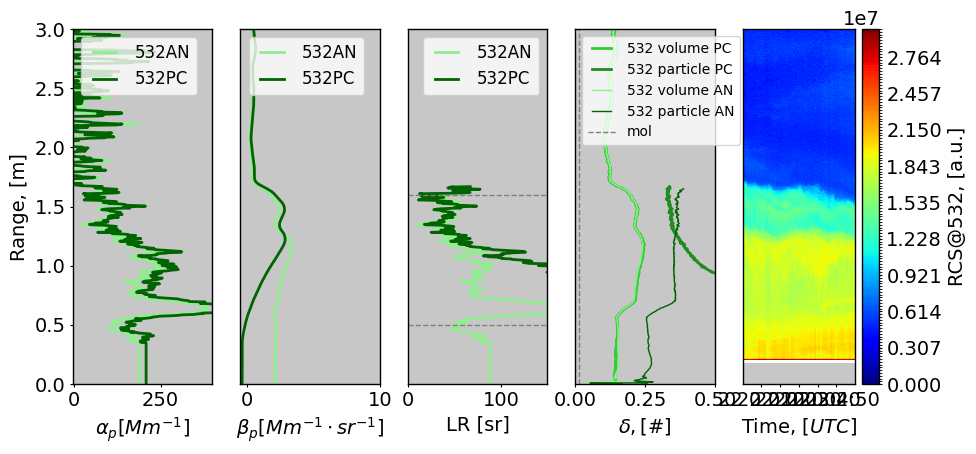

In [248]:
fig, ax = plt.subplots(ncols=5, nrows=1, figsize=(10, 5))
ymax = 3000

#Plot Extinction
ax[0].plot(1e6*alpha532, z/1000, lw=2, color = 'lightgreen', label=f'{wave}AN')
ax[0].plot(1e6*alpha532_pc, z/1000, lw=2, color = 'darkgreen', label=f'{wave}PC')
ax[0].set_xscale('linear')
ax[0].set_xlim(-5,400)
ax[0].set_ylim(0,ymax/1000)
ax[0].set_xlabel(r'$\alpha_{p} [Mm^{-1}]$')
ax[0].set_ylabel('Range, [m]')
ax[0].legend(loc='upper left')

#Plot beta
ax[1].plot(1e6*beta532, z, lw=2, color = 'lightgreen', label=f'{wave}AN')
ax[1].plot(1e6*beta532_pc, z, lw=2, color = 'darkgreen', label=f'{wave}PC')
ax[1].set_xscale('linear')
ax[1].set_yticks([])
ax[1].set_xlim(-0.5,10)
ax[1].set_ylim(0,ymax)
ax[1].set_xlabel(r'$\beta_{p} [Mm^{-1}\cdot sr^{-1}]$')
ax[1].legend(loc='upper left')

#Plot LR
ax[2].plot(LR_profile, z, lw=2, color = 'lightgreen', label=f'{wave}AN')
ax[2].plot(LR_profile_pc, z, lw=2, color = 'darkgreen', label=f'{wave}PC')
pbl_top = 500 
dust_top =1600 
ax[2].hlines(pbl_top,0,300,color='grey', ls='--')
ax[2].hlines(dust_top,0,300,color='grey', ls='--')
ax[2].set_xscale('linear')
ax[2].set_yticks([])
ax[2].set_ylim(0,ymax)
ax[2].set_xlim(0,150)
ax[2].set_xlabel('LR [sr]')
ax[2].legend()

#Plot Depol
ax[3].plot(lvdr_pc, z, lw= 2, c='limegreen', label=f"{wave} volume PC")
ax[3].plot(lpdr_pc, z, lw= 2, c='forestgreen', label=f"{wave} particle PC")
ax[3].plot(lvdr, z, lw= 1, c='lightgreen', label=f"{wave} volume AN")
ax[3].plot(lpdr, z, lw= 1, c='darkgreen', label=f"{wave} particle AN")
ax[3].vlines(mol_depo, 0, ymax, ls= '--', color='grey', label="mol")
ax[3].set_xscale('linear')
ax[3].set_yticks([])
ax[3].set_xlim(0,0.5)
ax[3].set_ylim(0,ymax)
ax[3].set_xlabel(r'$\delta, [\#]$')
ax[3].legend(loc='upper left', fontsize=10)

#Quicklook
from gfatpy.lidar.plot.quicklook import get_norm
scale_bounds = (0,3e7)
norm = get_norm(rcs, scale_bounds)
colormap = 'jet'
q = ax[4].pcolormesh(
    rcs.time, rcs.range, rcs.T, cmap=colormap, norm=norm,
)
cbar = fig.colorbar(q, ax=ax[4])

# # Define a custom formatter for the colorbar ticks
# def custom_formatter(x, pos):
#     return f'{x:.1E}'  # Format x with one decimal place

# # Apply the custom formatter to the x-axis ticks of the colorbar
# cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(custom_formatter))

ax[4].set_xlabel(r"Time, $[UTC]$")
ax[4].set_yticks([])
ax[4].set_ylim(0,ymax)
cbar.cmap.set_over("white")  # type: ignore
cbar.set_label(f'RCS@{wave}, [a.u.]')


In [249]:
# FF
channel = '355fta'
channel_pc = '355ftp'
channel_raman = '354fta'
channel_raman_pc = '354ftp'
wave = int(channel[:-3])
wave_raman = int(channel_raman[:-3])
R_threshold = 1.1
P_raman = lidar_sel[f'signal_{channel_raman}'].mean('time').values
P_raman_pc = lidar_sel[f'signal_{channel_raman_pc}'].mean('time').values
P_elastic = lidar_sel[f'signal_{channel}'].mean('time').values
P_elastic_pc = lidar_sel[f'signal_{channel_pc}'].mean('time').values

dz = z[1]-z[0]

alpha355 = raman.retrieve_extinction(
    P_raman,
    z,
    (wave, wave_raman),    
    ecmwf_data['pressure'].values,
    ecmwf_data['temperature'].values,        
    window_size_m = 75.
    )

alpha355_pc = raman.retrieve_extinction(
    P_raman_pc,
    z,
    (wave, wave_raman),    
    ecmwf_data['pressure'].values,
    ecmwf_data['temperature'].values,        
    window_size_m = 75.
    )


alpha355 = refill_overlap(alpha355, z, 350)
alpha355[z>5000.]  = 0.

alpha355_pc = refill_overlap(alpha355_pc, z, 350)
alpha355_pc[z>5000.]  = 0.


beta355 = raman.retrieve_backscatter(
    P_raman,
    P_elastic,
    alpha355,
    z,
    (wave, wave_raman),    
    ecmwf_data['pressure'].values,
    ecmwf_data['temperature'].values,        
    reference=(6000,7000)
    )

beta355 = savgol_filter(beta355, 15, 1, delta=dz, mode="nearest", cval=np.nan)
beta355 = refill_overlap(beta355, z, 350)

beta355_pc = raman.retrieve_backscatter(
    P_raman_pc,
    P_elastic_pc,
    alpha355_pc,
    z,
    (wave, wave_raman),    
    ecmwf_data['pressure'].values,
    ecmwf_data['temperature'].values,        
    reference=(6000,7000)
    )

beta355_pc = savgol_filter(beta355_pc, 15, 1, delta=dz, mode="nearest", cval=np.nan)
beta355_pc = refill_overlap(beta355_pc, z, 350)

#AN
beta_mol = atmo_data[wave]["molecular_beta"].values
R = beta355/beta_mol + 1 
LR_profile = alpha355/beta355#beta532
LR_profile[R<R_threshold] = np.nan

#PC
beta_mol = atmo_data[wave]["molecular_beta"].values
R_pc = beta355_pc/beta_mol + 1 
LR_profile_pc = alpha355_pc/beta355_pc#beta532
LR_profile_pc[R_pc<R_threshold] = np.nan

#AN
lvdr_sel = lidar_sel.linear_volume_depolarization_ratio_355fa
mol_depo = atmo_data[wave]["molecular_depolarization"].values
lpdr_sel = particle_depolarization(lvdr_sel.values, R, mol_depo, lidar_sel.time.values, lidar_sel.range.values)

lvdr = lvdr_sel.sel(time=slice(*time_tuple)).mean('time')
lpdr = lpdr_sel.sel(time=slice(*time_tuple)).mean('time')
lpdr[R<R_threshold] = np.nan

#PC
lvdr_pc_sel = lidar_sel.linear_volume_depolarization_ratio_355fp
mol_depo = atmo_data[wave]["molecular_depolarization"].values
lpdr_pc_sel = particle_depolarization(lvdr_pc_sel.values, R_pc, mol_depo, lidar_sel.time.values, lidar_sel.range.values)

lvdr_pc = lvdr_pc_sel.sel(time=slice(*time_tuple)).mean('time')
lpdr_pc = lpdr_pc_sel.sel(time=slice(*time_tuple)).mean('time')
lpdr_pc[R_pc<R_threshold] = np.nan
#RCS
rcs = lidar_sel[f'signal_{channel}']*z**2

#Print values
"LR[PBL]@355nm = " + f"{np.mean(LR_profile[z<pbl_top]):.1f}" + "+-" + f"{np.std(LR_profile[z<pbl_top]):.1f}" + " sr", \
"LR[DUST]@355nm = " + f"{np.mean(LR_profile[np.logical_and(z>pbl_top+250,z<dust_top)]):.1f}"+ "+-" + f"{np.std(LR_profile[np.logical_and(z>pbl_top+250,z<dust_top)]):.1f}" + " sr"

C:\Users\Usuario\Documents\gitlab\gfatpy\.venv\lib\site-packages\dask\core.py:119: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
C:\Users\Usuario\Documents\gitlab\gfatpy\.venv\lib\site-packages\dask\core.py:119: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
C:\Users\Usuario\Documents\gitlab\gfatpy\.venv\lib\site-packages\dask\core.py:119: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
C:\Users\Usuario\Documents\gitlab\gfatpy\.venv\lib\site-packages\dask\core.py:119: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
C:\Users\Usuario\Documents\gitlab\gfatpy\gfatpy\lidar\retrieval\raman.py:145: RuntimeWarning: invalid value encountered in divide
  gain_ratio = (signal_emission / signal_raman) * (T_raman/T_elastic) * (beta_mol_raman/beta_at_refere

('LR[PBL]@355nm = 43.9+-4.9 sr', 'LR[DUST]@355nm = 60.6+-4.8 sr')

C:\Users\Usuario\Documents\gitlab\gfatpy\.venv\lib\site-packages\dask\core.py:119: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


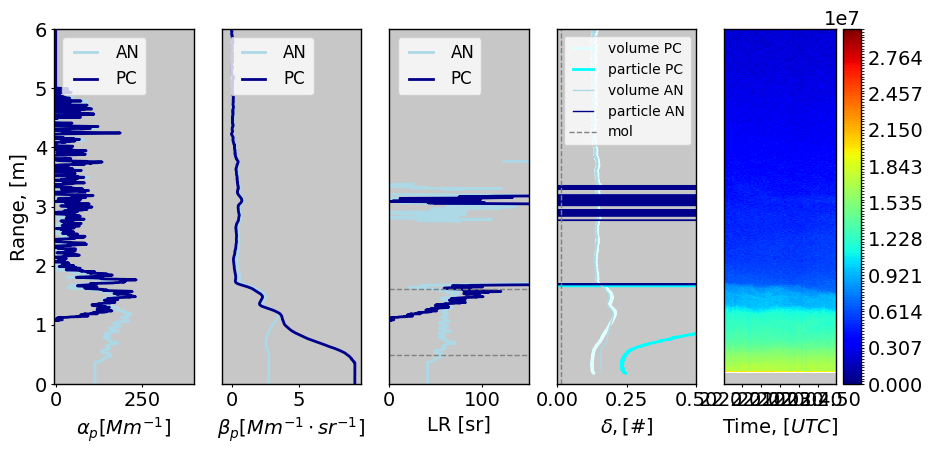

In [250]:
fig, ax = plt.subplots(ncols=5, nrows=1, figsize=(10, 5))
ymax = 6000

#Plot Extinction
ax[0].plot(1e6*alpha355, z/1000, lw=2, color = 'lightblue', label='AN')
ax[0].plot(1e6*alpha355_pc, z/1000, lw=2, color = 'darkblue', label='PC')
ax[0].set_xscale('linear')
ax[0].set_xlim(-5,400)
ax[0].set_ylim(0,ymax/1000)
ax[0].set_xlabel(r'$\alpha_{p} [Mm^{-1}]$')
ax[0].set_ylabel('Range, [m]')
ax[0].legend(loc='upper left')

#Plot beta
ax[1].plot(1e6*beta355, z, lw=2, color = 'lightblue', label='AN')
ax[1].plot(1e6*beta355_pc, z, lw=2, color = 'darkblue', label='PC')
ax[1].set_xscale('linear')
ax[1].set_yticks([])
ax[1].set_ylim(0,ymax)
ax[1].set_xlabel(r'$\beta_{p} [Mm^{-1}\cdot sr^{-1}]$')
ax[1].legend(loc='upper left')

#Plot LR
ax[2].plot(LR_profile, z, lw=2, color = 'lightblue', label='AN')
ax[2].plot(LR_profile_pc, z, lw=2, color = 'darkblue', label='PC')
pbl_top = 500 
dust_top =1600 
ax[2].hlines(pbl_top,0,300,color='grey', ls='--')
ax[2].hlines(dust_top,0,300,color='grey', ls='--')
ax[2].set_xscale('linear')
ax[2].set_yticks([])
ax[2].set_ylim(0,ymax)
ax[2].set_xlim(0,150)
ax[2].set_xlabel('LR [sr]')
ax[2].legend(loc='upper left')

#Plot Depol
ax[3].plot(lvdr_pc, z, lw= 2, c='lightcyan', label="volume PC")
ax[3].plot(lpdr_pc, z, lw= 2, c='cyan', label="particle PC")
ax[3].plot(lvdr, z, lw= 1, c='lightblue', label="volume AN")
ax[3].plot(lpdr, z, lw= 1, c='darkblue', label="particle AN")
ax[3].vlines(mol_depo, 0, ymax, ls= '--', color='grey', label="mol")
ax[3].set_xscale('linear')
ax[3].set_yticks([])
ax[3].set_xlim(0,0.5)
ax[3].set_ylim(0,ymax)
ax[3].set_xlabel(r'$\delta, [\#]$')
ax[3].legend(loc='upper left', fontsize=10)

#Quicklook
from gfatpy.lidar.plot.quicklook import get_norm
scale_bounds = (0,3e7)
norm = get_norm(rcs, scale_bounds)
colormap = 'jet'
q = ax[4].pcolormesh(
    rcs.time, rcs.range, rcs.T, cmap=colormap, norm=norm,
)

ax[4].set_xlabel(r"Time, $[UTC]$")
ax[4].set_yticks([])
ax[4].set_ylim(0,ymax)
q.cmap.set_over("white")  # type: ignore
q.set_label('RCS, [a.u.]')
fig.colorbar(q)

In [252]:
# NF
channel = '355nta'
channel_pc = '355ntp'
channel_raman = '387nta'
channel_raman_pc = '387ntp'
wave = int(channel[:-3])
wave_raman = int(channel_raman[:-3])
R_threshold = 1.1
P_raman = lidar_sel[f'signal_{channel_raman}'].mean('time').values
P_raman_pc = lidar_sel[f'signal_{channel_raman_pc}'].mean('time').values
P_elastic = lidar_sel[f'signal_{channel}'].mean('time').values
P_elastic_pc = lidar_sel[f'signal_{channel_pc}'].mean('time').values

dz = z[1]-z[0]

alpha355 = raman.retrieve_extinction(
    P_raman,
    z,
    (wave, wave_raman),    
    ecmwf_data['pressure'].values,
    ecmwf_data['temperature'].values,        
    window_size_m = 75.
    )

alpha355_pc = raman.retrieve_extinction(
    P_raman_pc,
    z,
    (wave, wave_raman),    
    ecmwf_data['pressure'].values,
    ecmwf_data['temperature'].values,        
    window_size_m = 75.
    )


alpha355 = refill_overlap(alpha355, z, 350)
alpha355[z>5000.]  = 0.

alpha355_pc = refill_overlap(alpha355_pc, z, 350)
alpha355_pc[z>5000.]  = 0.


beta355 = raman.retrieve_backscatter(
    P_raman,
    P_elastic,
    alpha355,
    z,
    (wave, wave_raman),    
    ecmwf_data['pressure'].values,
    ecmwf_data['temperature'].values,        
    reference=(6000,7000)
    )

beta355 = savgol_filter(beta355, 15, 1, delta=dz, mode="nearest", cval=np.nan)
beta355 = refill_overlap(beta355, z, 350)

beta355_pc = raman.retrieve_backscatter(
    P_raman_pc,
    P_elastic_pc,
    alpha355_pc,
    z,
    (wave, wave_raman),    
    ecmwf_data['pressure'].values,
    ecmwf_data['temperature'].values,        
    reference=(6000,7000)
    )

beta355_pc = savgol_filter(beta355_pc, 15, 1, delta=dz, mode="nearest", cval=np.nan)
beta355_pc = refill_overlap(beta355_pc, z, 350)

#AN
beta_mol = atmo_data[wave]["molecular_beta"].values
R = beta355/beta_mol + 1 
LR_profile = alpha355/beta355#beta532
LR_profile[R<R_threshold] = np.nan

#PC
beta_mol = atmo_data[wave]["molecular_beta"].values
R_pc = beta355_pc/beta_mol + 1 
LR_profile_pc = alpha355_pc/beta355_pc#beta532
LR_profile_pc[R_pc<R_threshold] = np.nan

#AN
lvdr_sel = lidar_sel.linear_volume_depolarization_ratio_355fa
mol_depo = atmo_data[wave]["molecular_depolarization"].values
lpdr_sel = particle_depolarization(lvdr_sel.values, R, mol_depo, lidar_sel.time.values, lidar_sel.range.values)

lvdr = lvdr_sel.sel(time=slice(*time_tuple)).mean('time')
lpdr = lpdr_sel.sel(time=slice(*time_tuple)).mean('time')
lpdr[R<R_threshold] = np.nan

#PC
lvdr_pc_sel = lidar_sel.linear_volume_depolarization_ratio_355fp
mol_depo = atmo_data[wave]["molecular_depolarization"].values
lpdr_pc_sel = particle_depolarization(lvdr_pc_sel.values, R_pc, mol_depo, lidar_sel.time.values, lidar_sel.range.values)

lvdr_pc = lvdr_pc_sel.sel(time=slice(*time_tuple)).mean('time')
lpdr_pc = lpdr_pc_sel.sel(time=slice(*time_tuple)).mean('time')
lpdr_pc[R_pc<R_threshold] = np.nan
#RCS
rcs = lidar_sel[f'signal_{channel}']*z**2

#Print values
"LR[PBL]@355nm = " + f"{np.mean(LR_profile[z<pbl_top]):.1f}" + "+-" + f"{np.std(LR_profile[z<pbl_top]):.1f}" + " sr", \
"LR[DUST]@355nm = " + f"{np.mean(LR_profile[np.logical_and(z>pbl_top+250,z<dust_top)]):.1f}"+ "+-" + f"{np.std(LR_profile[np.logical_and(z>pbl_top+250,z<dust_top)]):.1f}" + " sr"

('LR[PBL]@355nm = 39.7+-3.3 sr', 'LR[DUST]@355nm = 68.8+-18.4 sr')

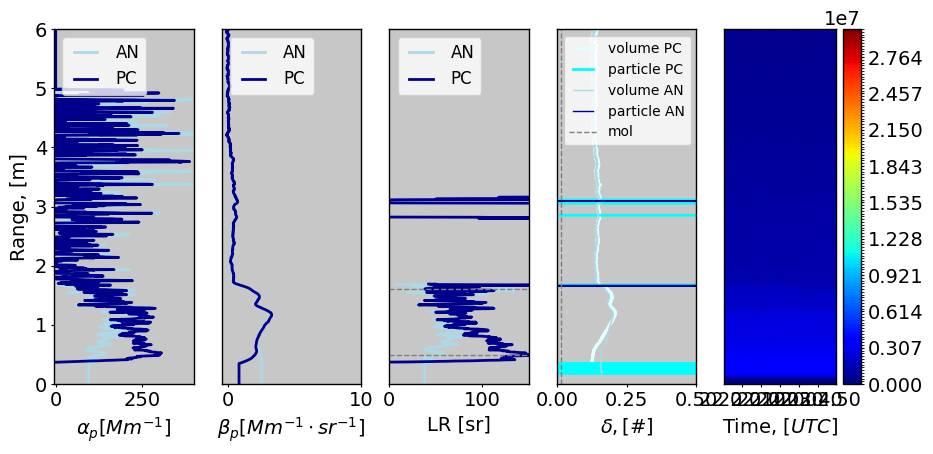

In [253]:
fig, ax = plt.subplots(ncols=5, nrows=1, figsize=(10, 5))
ymax = 6000

#Plot Extinction
ax[0].plot(1e6*alpha355, z/1000, lw=2, color = 'lightblue', label='AN')
ax[0].plot(1e6*alpha355_pc, z/1000, lw=2, color = 'darkblue', label='PC')
ax[0].set_xscale('linear')
ax[0].set_xlim(-5,400)
ax[0].set_ylim(0,ymax/1000)
ax[0].set_xlabel(r'$\alpha_{p} [Mm^{-1}]$')
ax[0].set_ylabel('Range, [m]')
ax[0].legend(loc='upper left')

#Plot beta
ax[1].plot(1e6*beta355, z, lw=2, color = 'lightblue', label='AN')
ax[1].plot(1e6*beta355_pc, z, lw=2, color = 'darkblue', label='PC')
ax[1].set_xscale('linear')
ax[1].set_yticks([])
ax[1].set_ylim(0,ymax)
ax[1].set_xlim(-0.5,10)
ax[1].set_xlabel(r'$\beta_{p} [Mm^{-1}\cdot sr^{-1}]$')
ax[1].legend(loc='upper left')

#Plot LR
ax[2].plot(LR_profile, z, lw=2, color = 'lightblue', label='AN')
ax[2].plot(LR_profile_pc, z, lw=2, color = 'darkblue', label='PC')
pbl_top = 500 
dust_top =1600 
ax[2].hlines(pbl_top,0,300,color='grey', ls='--')
ax[2].hlines(dust_top,0,300,color='grey', ls='--')
ax[2].set_xscale('linear')
ax[2].set_yticks([])
ax[2].set_ylim(0,ymax)
ax[2].set_xlim(0,150)
ax[2].set_xlabel('LR [sr]')
ax[2].legend(loc='upper left')

#Plot Depol
ax[3].plot(lvdr_pc, z, lw= 2, c='lightcyan', label="volume PC")
ax[3].plot(lpdr_pc, z, lw= 2, c='cyan', label="particle PC")
ax[3].plot(lvdr, z, lw= 1, c='lightblue', label="volume AN")
ax[3].plot(lpdr, z, lw= 1, c='darkblue', label="particle AN")
ax[3].vlines(mol_depo, 0, ymax, ls= '--', color='grey', label="mol")
ax[3].set_xscale('linear')
ax[3].set_yticks([])
ax[3].set_xlim(0,0.5)
ax[3].set_ylim(0,ymax)
ax[3].set_xlabel(r'$\delta, [\#]$')
ax[3].legend(loc='upper left', fontsize=10)

#Quicklook
from gfatpy.lidar.plot.quicklook import get_norm
scale_bounds = (0,3e7)
norm = get_norm(rcs, scale_bounds)
colormap = 'jet'
q = ax[4].pcolormesh(
    rcs.time, rcs.range, rcs.T, cmap=colormap, norm=norm,
)

ax[4].set_xlabel(r"Time, $[UTC]$")
ax[4].set_yticks([])
ax[4].set_ylim(0,ymax)
q.cmap.set_over("white")  # type: ignore
q.set_label('RCS, [a.u.]')
fig.colorbar(q)